# ***Problem Statement***
Yulu wants to identify the factors affecting the demand for shared electric bikes and understand how variables like weather, season, and working days influence bike rentals.

# ***Objective***


1.   Perform EDA to understand data patterns and relationships.
2.   Analyze the impact of working day, season, weather, temperature, etc. on bike rentals.
1.   Apply statistical tests (T-Test, ANOVA, Chi-Square) to validate business hypotheses.

2.   Generate insights and recommendations to improve demand forecasting and business decisions.


Yulu aims to understand the key factors driving electric bike rental demand so the company can improve revenue, optimize bike availability, enhance customer experience, and make data-driven operational and marketing decisions.

# ***Insights - EDA***



1.   **The Core Revenue Engine:** Regular, registered subscribers are the absolute backbone of business, showing a massive +0.97 correlation with total ride volumes. Because they ride out of pure necessity, commuting to work or university—their habits are steady, predictable, and largely immune to minor daily weather shifts.
2.   **The High-Margin Casual Surge:** Casual riders behave like an entirely different customer segment. Their volumes are incredibly elastic, spiking massively on weekends, holidays, and during pleasant seasons. While harder to predict day-to-day, capturing this leisure audience is your biggest lever for high-margin revenue spikes.


1.   **A Tale of Two Daily Mindsets:** The hourly patterns show that people use Yulu bikes for completely different reasons depending on the day. Workdays experience an intense, **bimodal** "twin peak" at 8:00 AM and 5:00 PM as commuters try to beat traffic, while weekends and holidays reveal a relaxed **bell-curve trend** that tops out smoothly between 12:00 PM and 4:00 PM.
2.  **Rethinking the "Outliers":** While standard statistical boundaries flag high-volume hours (anything above 647 total rides) as anomalies or outliers, these are not errors to be wiped from the data. They are thr most valuable operational stress-tests—the exact golden windows where Yuluu service capacity is stretched to its absolute limits.



1.   **The Golden Operational Seasons:** Nature acts as a major volume control knob for the fleet. Fall and Summer emerge as clear peak seasons because they offer comfortable riding environments, whereas Spring drops off as weakest period, making it the perfect seasonal window to pull bikes back for heavy maintenance and battery overhauls.
2.   **The Absolute Dealbreaker:** While everyday environmental factors like windspeed have almost zero impact on a user's choice to ride, precipitation changes the game instantly. Moving from clear skies to "Light Rain or Snow" triggers a severe drop in ridership, and heavy downpours flatten demand to absolute zero.



1.   **The Hidden Drag Coefficient (Humidity):** Aside from direct rainfall, relative humidity acts as a silent, strong deterrent to your volume, sharing a clear negative correlation (-0.32) with rentals. As the air gets sticky and uncomfortable before a rainstorm, users actively drop two-wheelers in favor of enclosed transit.
2.   **The Multi-Collinearity Trap for Data Models:** From a technical forecasting standpoint, actual temperature (temp) and feeling temperature (atemp) share a nearly identical overlapping trajectory with a +0.98 correlation. If you try to feed both into a predictive model to forecast future demand, they will distort your coefficients; we must drop one entirely to keep our forecasts clean.









# ***Insights - Hypothesis Testing***



1.   **Working Days vs. Weekends (T-Test)**: Total daily rental demand remains practically identical whether it's a workday or a weekend. The total market size doesn't shrink when offices close; instead, user intent simply shifts from structured morning/evening commutes to relaxed, spread-out weekend afternoon leisure trips.
2.   **Weather & Seasonal Link (Chi-Square)**: Extreme weather isn't random—it predictably clusters around specific seasons (like heavy rain and cold grouping in Spring). This means bad weather creates a compounding drop in bike usage that we can map out and plan for well in advance, rather than reacting day by day.



1.   **The Seasonal Dial (ANOVA)**: Changing seasons act like a macro volume control knob for the entire business. Summer and Fall naturally push rentals to peak volumes due to comfortable outdoor temperatures, while Spring hits a massive statistical low, proving that our revenue is highly climate-driven.
2.   **The Ultimate Revenue Dealbreaker (ANOVA)**: Weather conditions are the single greatest threat to daily operations. The moment the sky transitions from clear or cloudy into light rain or snow, customer demand immediately falls off a cliff, dropping down to near-zero during heavy downpours





# ***Recommendation***



1. **Dynamic Pricing Engine**: Implement context-aware rates in the app. Introduce a premium "Leisure Multiplier" for casual riders during high-demand weekend afternoons, and push automatic discounts to commuters on highly humid or overcast weekdays to stop them from switching to cabs.
2.   **Targeted Fleet Rebalancing:** Move logistics away from a "one-size-fits-all" model. On weekdays, flood residential hubs before 7:30 AM and office parks before 4:30 PM. On weekends, shift 80% of the active fleet directly to parks, shopping districts, and recreational hotspots by 11:00 AM.



1.   **Predictive Maintenance Windows**: Turn the low-demand Spring season into an operational asset. Schedule all heavy vehicle overhauls, battery degradation testing, and deep structural safety checks during this slow window to ensure a 98% fleet availability rate when the Summer rush hits.
2.   **Automated Weather Protocol**: Integrate live weather forecasting APIs directly into the backend platform. The moment a heavy rain threshold is triggered in a specific zone, automatically pause roadside battery-swapping tasks to cut costs and prompt ground teams to move exposed bikes under shelter.



1.   **Clean the Forecasting Code**: Have the engineering team drop feeling temperature (atemp) from our demand prediction models completely. It shares a near-perfect $+0.98$ correlation with actual temperature (temp), creating data noise (multicollinearity) that is currently blurring our inventory forecasts.







In [ ]:
# import libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import ttest_1samp, ttest_ind, ttest_rel,chisquare,chi2_contingency
import statsmodels.api as sm
from statsmodels.formula.api import ols

In [ ]:
# Importing the Yulu data into Colab

url = "https://docs.google.com/spreadsheets/d/1VjEnYCPmDMF672g_rgYjdVtv8ls9eTJRHjFLcNMRwpE/export?format=csv"
yulu = pd.read_csv(url)

NameError: name 'pd' is not defined

In [ ]:
yulu.head(5)

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 0:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 1:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 2:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 3:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 4:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


# ***Data Overview***

In [ ]:
# Summary of the DataFrame, including the index, data types, and non-null values. Using info
yulu.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB


In [ ]:
# Checking number of rows and columns
yulu.shape

(10886, 12)

In [ ]:
# Generate summary statistics for all columns (numeric + categorical + object) in a DataFrameyulu.describe()
yulu.describe(include = 'all')

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
count,10886,10886.000000,10886.000000,10886.000000,10886.000000,10886.00000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000
unique,10886,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,2012-12-19 23:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,2.506614,0.028569,0.680875,1.418427,20.23086,23.655084,61.886460,12.799395,36.021955,155.552177,191.574132
std,NaN,1.116174,0.166599,0.466159,0.633839,7.79159,8.474601,19.245033,8.164537,49.960477,151.039033,181.144454
min,NaN,1.000000,0.000000,0.000000,1.000000,0.82000,0.760000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,NaN,2.000000,0.000000,0.000000,1.000000,13.94000,16.665000,47.000000,7.001500,4.000000,36.000000,42.000000
50%,NaN,3.000000,0.000000,1.000000,1.000000,20.50000,24.240000,62.000000,12.998000,17.000000,118.000000,145.000000
75%,NaN,4.000000,0.000000,1.000000,2.000000,26.24000,31.060000,77.000000,16.997900,49.000000,222.000000,284.000000


In [ ]:
# Check Missing Values
yulu.isnull().sum()

,0
datetime,0
season,0
holiday,0
workingday,0
weather,0
temp,0
atemp,0
humidity,0
windspeed,0
casual,0


# ***Feature Engineering***

In [ ]:
# Converting date time to timestamp
yulu['date_timestamp'] = pd.to_datetime(yulu['datetime'])

In [ ]:
# Extracting Date,Hour, Day, Month
yulu['date'] = yulu['date_timestamp'].dt.date
yulu['day'] = yulu['date_timestamp'].dt.day_name()
yulu['hour'] = yulu['date_timestamp'].dt.hour
yulu['month'] = yulu['date_timestamp'].dt.month
yulu['month_name'] = yulu['date_timestamp'].dt.month_name()

In [ ]:
# Mapping categorical variables - Season and Weather Mapping
season_map = {1: 'Spring',2: 'Summer',3: 'Fall',4: 'Winter'}
weather_map = {1: 'Clear',2: 'Mist + Cloudy',3: 'Light Rain/Snow',4: 'Heavy Rain'}
yulu['season_name'] = yulu['season'].map(season_map)
yulu['weather_name'] = yulu['weather'].map(weather_map)

In [ ]:
yulu.head(5)

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,date_timestamp,date,day,hour,month,month_name,season_name,weather_name
0,2011-01-01 0:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,2011-01-01 00:00:00,2011-01-01,Saturday,0,1,January,Spring,Clear
1,2011-01-01 1:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,2011-01-01 01:00:00,2011-01-01,Saturday,1,1,January,Spring,Clear
2,2011-01-01 2:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2011-01-01 02:00:00,2011-01-01,Saturday,2,1,January,Spring,Clear
3,2011-01-01 3:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,2011-01-01 03:00:00,2011-01-01,Saturday,3,1,January,Spring,Clear
4,2011-01-01 4:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,2011-01-01 04:00:00,2011-01-01,Saturday,4,1,January,Spring,Clear


In [ ]:
# Re-naming the columns
yulu.rename(columns = {'casual':'casual_users_count','registered':'reg_users_count','count':'overall_count'},inplace=True)

In [ ]:
# Re-arranging the columns
yulu[['datetime','date_timestamp','date','day','hour','month','month_name','season','season_name','weather','weather_name','holiday','workingday','temp','atemp','humidity','windspeed','casual_users_count','reg_users_count','overall_count']]

,datetime,date_timestamp,date,day,hour,month,month_name,season,season_name,weather,weather_name,holiday,workingday,temp,atemp,humidity,windspeed,casual_users_count,reg_users_count,overall_count
0,2011-01-01 0:00:00,2011-01-01 00:00:00,2011-01-01,Saturday,0,1,January,1,Spring,1,Clear,0,0,9.84,14.395,81,0.0000,3,13,16
1,2011-01-01 1:00:00,2011-01-01 01:00:00,2011-01-01,Saturday,1,1,January,1,Spring,1,Clear,0,0,9.02,13.635,80,0.0000,8,32,40
2,2011-01-01 2:00:00,2011-01-01 02:00:00,2011-01-01,Saturday,2,1,January,1,Spring,1,Clear,0,0,9.02,13.635,80,0.0000,5,27,32
3,2011-01-01 3:00:00,2011-01-01 03:00:00,2011-01-01,Saturday,3,1,January,1,Spring,1,Clear,0,0,9.84,14.395,75,0.0000,3,10,13
4,2011-01-01 4:00:00,2011-01-01 04:00:00,2011-01-01,Saturday,4,1,January,1,Spring,1,Clear,0,0,9.84,14.395,75,0.0000,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10881,2012-12-19 19:00:00,2012-12-19 19:00:00,2012-12-19,Wednesday,19,12,December,4,Winter,1,Clear,0,1,15.58,19.695,50,26.0027,7,329,336
10882,2012-12-19 20:00:00,2012-12-19 20:00:00,2012-12-19,Wednesday,20,12,December,4,Winter,1,Clear,0,1,14.76,17.425,57,15.0013,10,231,241
10883,2012-12-19 21:00:00,2012-12-19 21:00:00,2012-12-19,Wednesday,21,12,December,4,Winter,1,Clear,0,1,13.94,15.910,61,15.0013,4,164,168
10884,2012-12-19 22:00:00,2012-12-19 22:00:00,2012-12-19,Wednesday,22,12,December,4,Winter,1,Clear,0,1,13.94,17.425,61,6.0032,12,117,129


# ***Univariate Analysis - Continuous Variable***

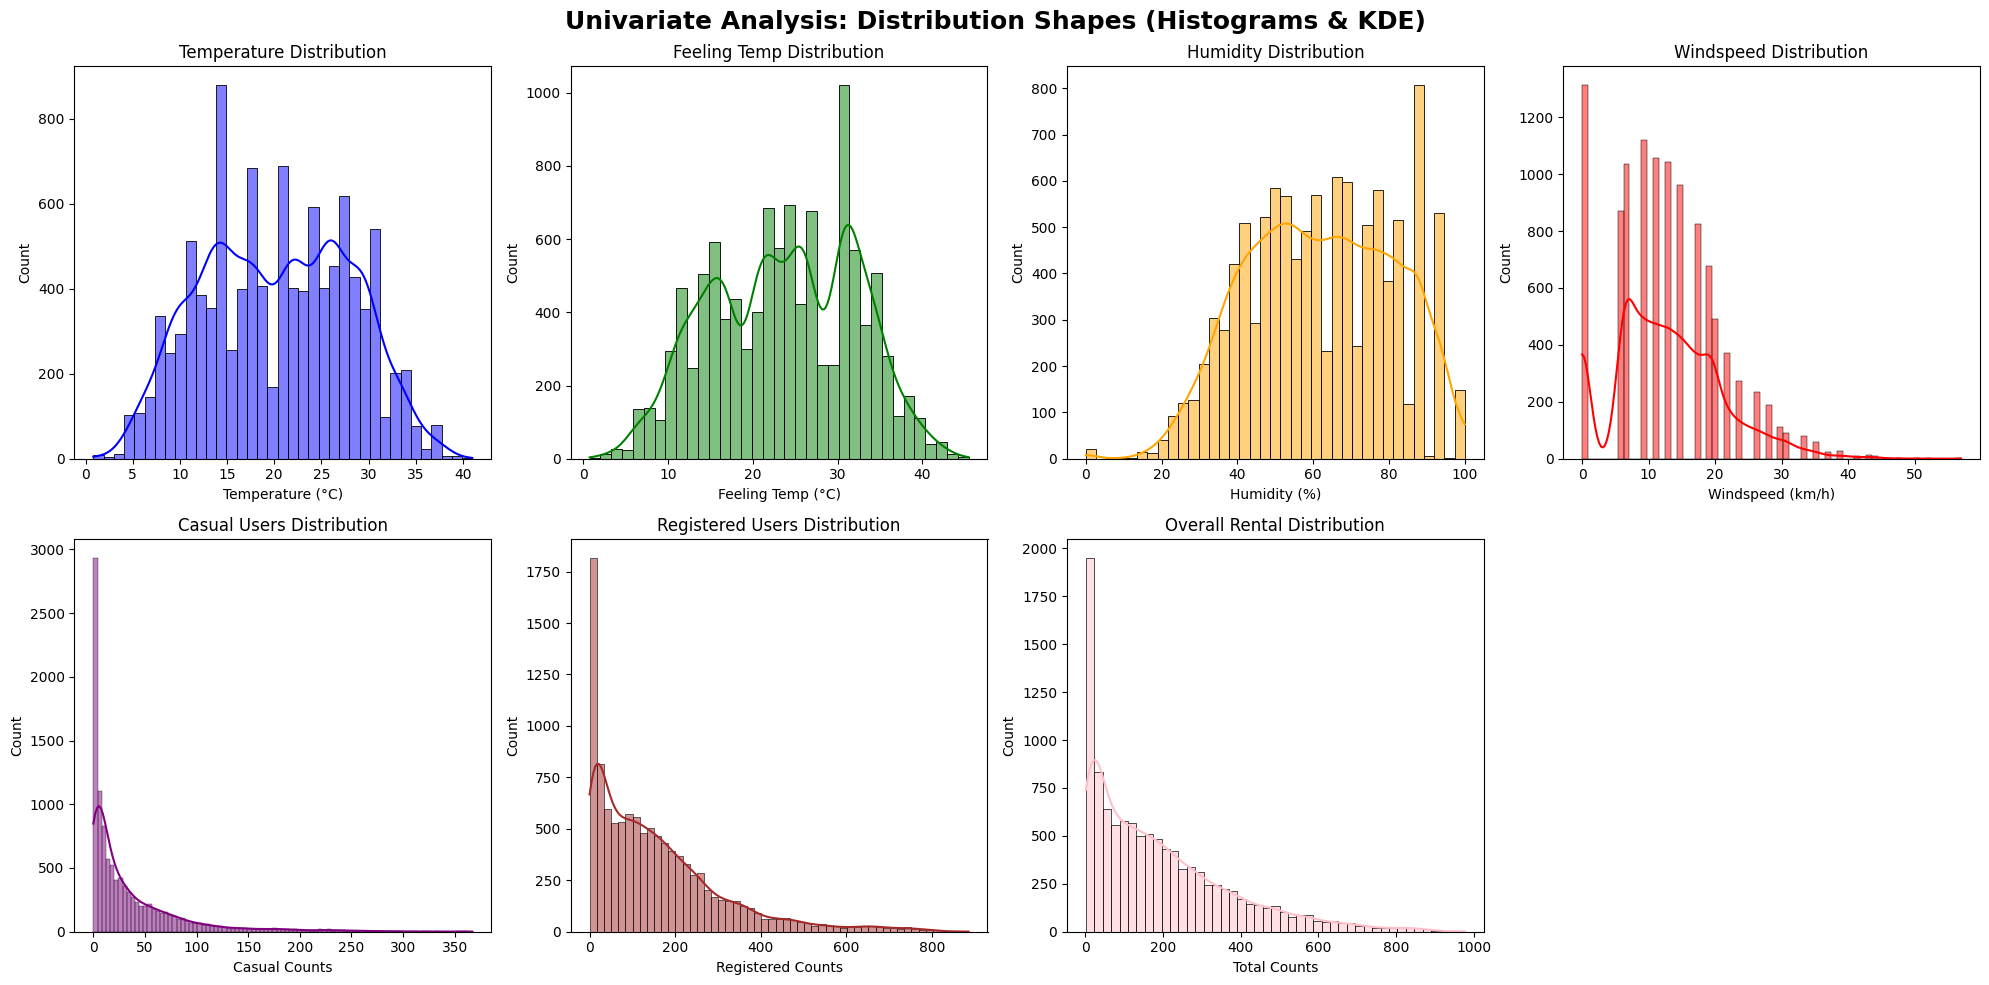

In [ ]:
# Set up the figure for Histograms/Distributions (2 Rows, 4 Columns grid)
fig = plt.figure(figsize=(20, 10))

# 1. Temperature
plt.subplot(2, 4, 1)
sns.histplot(yulu['temp'], kde=True, color='blue')
plt.title("Temperature Distribution")
plt.xlabel("Temperature (°C)")

# 2. ATemperature
plt.subplot(2, 4, 2)
sns.histplot(yulu['atemp'], kde=True, color='green')
plt.title("Feeling Temp Distribution")
plt.xlabel("Feeling Temp (°C)")

# 3. Humidity
plt.subplot(2, 4, 3)
sns.histplot(yulu['humidity'], kde=True, color='orange')
plt.title("Humidity Distribution")
plt.xlabel("Humidity (%)")

# 4. Windspeed
plt.subplot(2, 4, 4)
sns.histplot(yulu['windspeed'], kde=True, color='red')
plt.title("Windspeed Distribution")
plt.xlabel("Windspeed (km/h)")

# 5. Casual Users Count
plt.subplot(2, 4, 5)
sns.histplot(yulu['casual_users_count'], kde=True, color='purple')
plt.title("Casual Users Distribution")
plt.xlabel("Casual Counts")

# 6. Registered Users Count
plt.subplot(2, 4, 6)
sns.histplot(yulu['reg_users_count'], kde=True, color='brown')
plt.title("Registered Users Distribution")
plt.xlabel("Registered Counts")

# 7. Overall Count
plt.subplot(2, 4, 7)
sns.histplot(yulu['overall_count'], kde=True, color='pink')
plt.title("Overall Rental Distribution")
plt.xlabel("Total Counts")

# Super title and layout adjustments
fig.suptitle('Univariate Analysis: Distribution Shapes (Histograms & KDE)', fontsize=18, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

# ***Univariate Analysis - Categorical Variables***

/tmp/ipykernel_487/987152639.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=yulu, x='day', order=day_order, palette='GnBu_d')
/tmp/ipykernel_487/987152639.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=yulu, x='month_name', order=month_order, palette='Oranges_r')


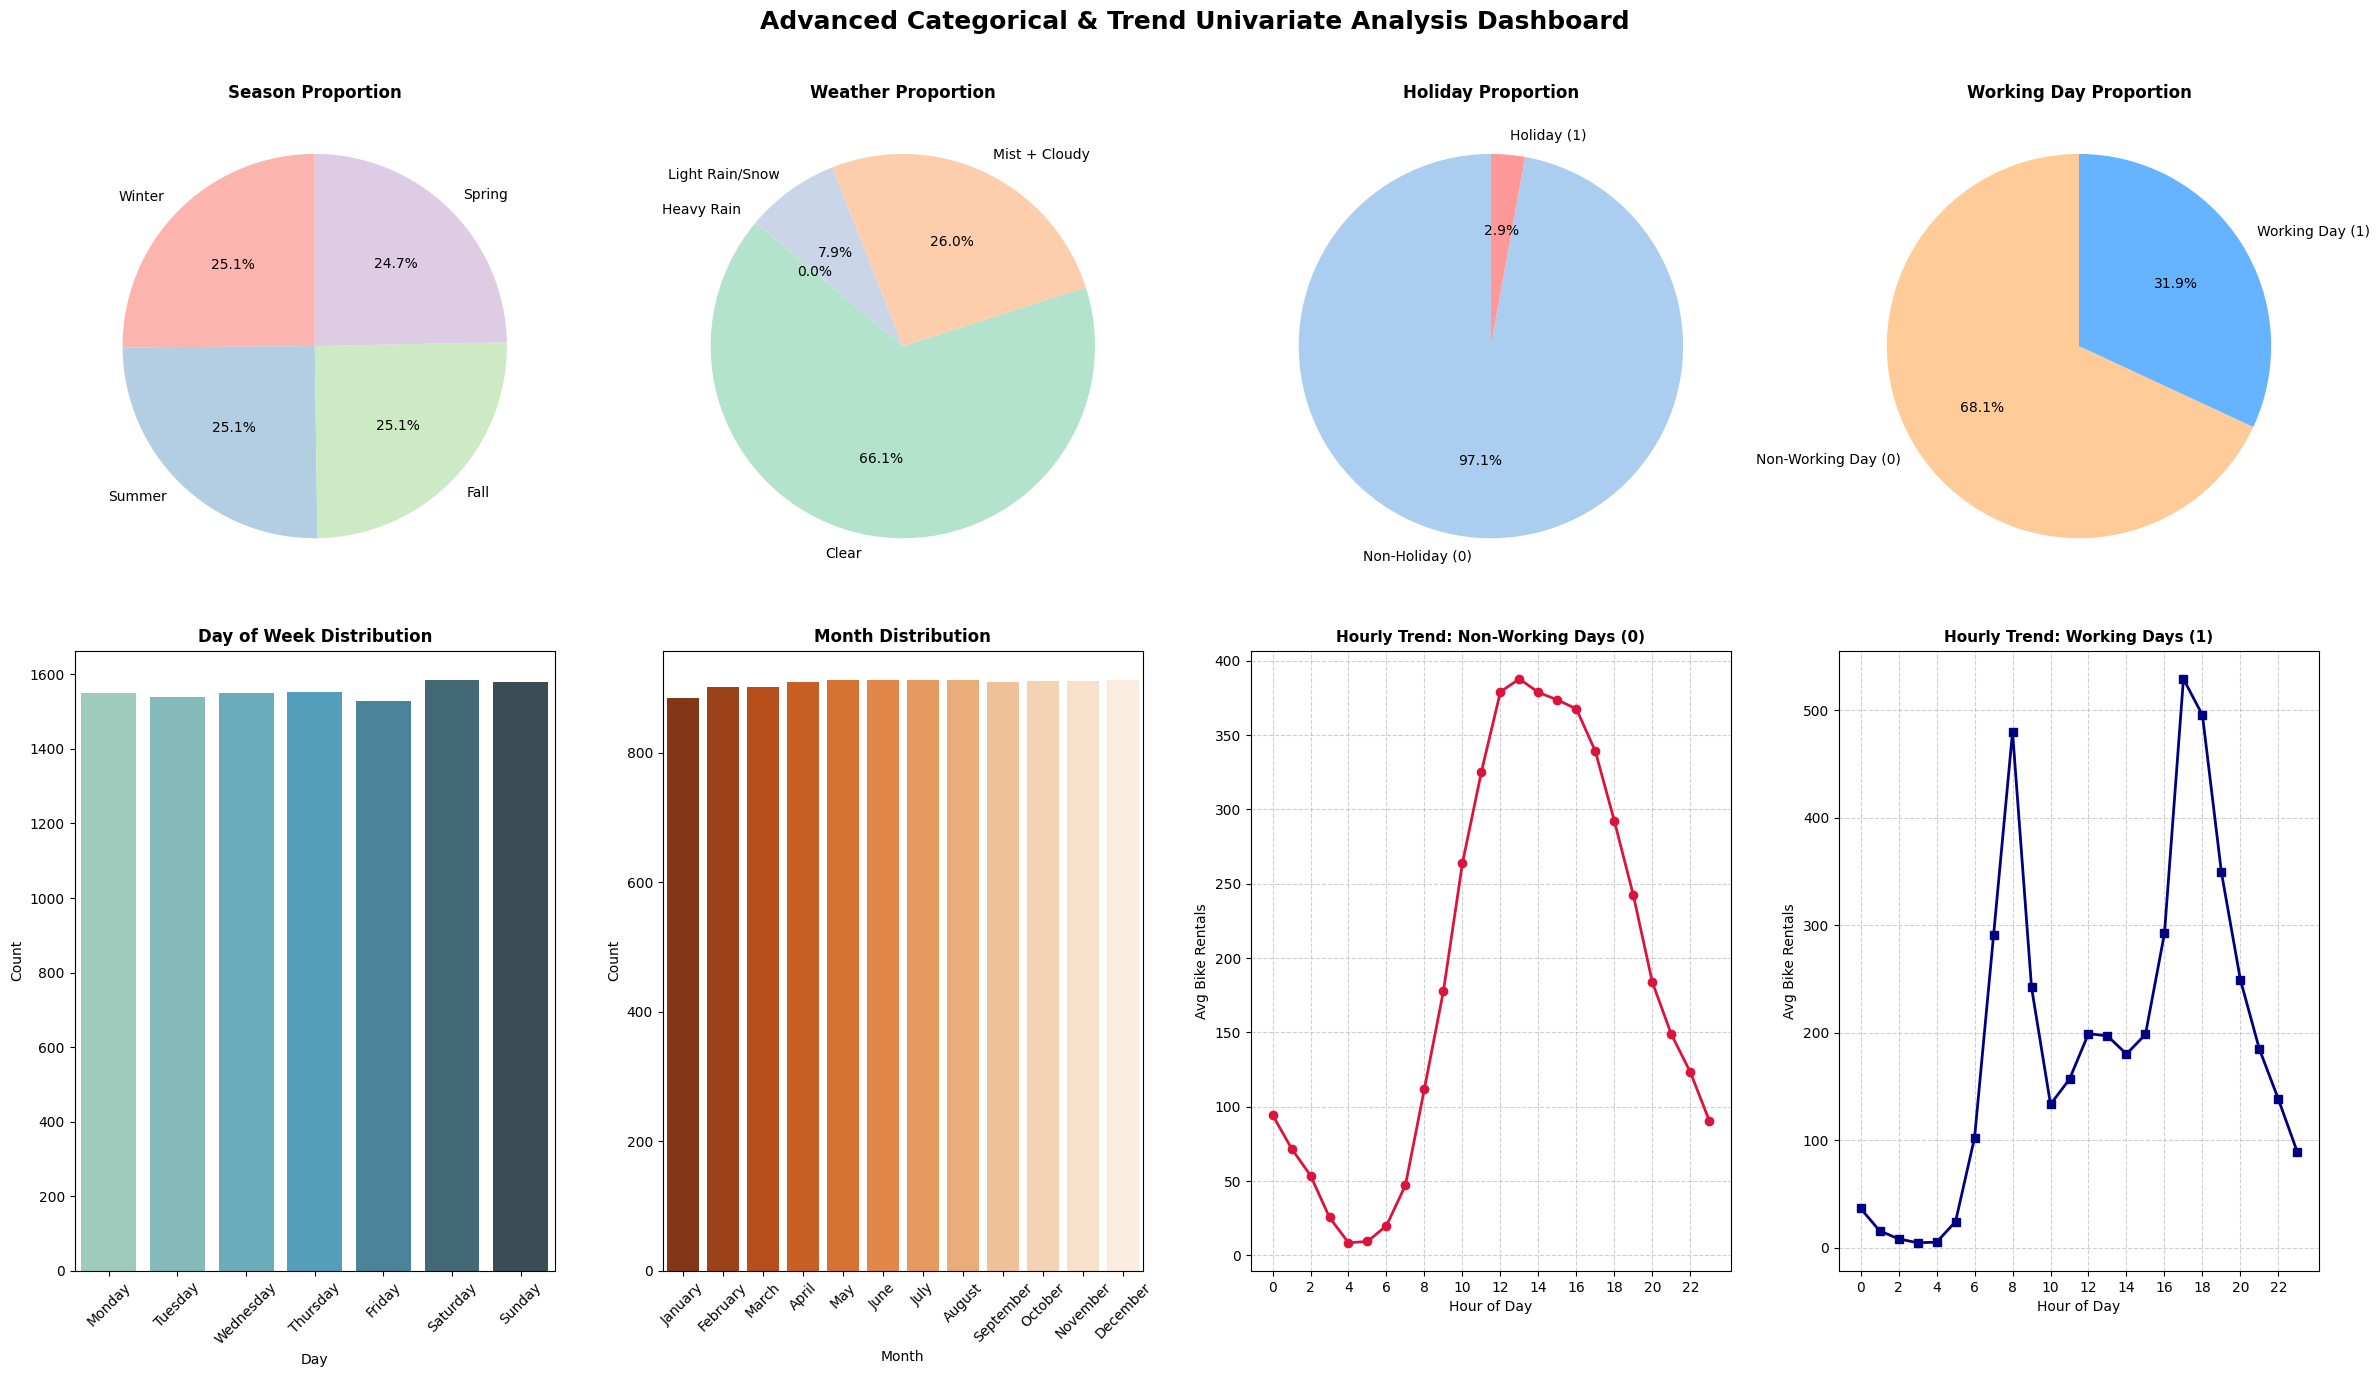

In [ ]:
fig = plt.figure(figsize=(24, 14))

# 1. Season Distribution
plt.subplot(2, 4, 1)
season_counts = yulu['season_name'].value_counts()
plt.pie(season_counts, labels=season_counts.index, autopct='%1.1f%%',
        colors=sns.color_palette('Pastel1'), startangle=90)
plt.title("Season Proportion", fontsize=12, fontweight='bold')

# 2. Weather Distribution
plt.subplot(2, 4, 2)
weather_counts = yulu['weather_name'].value_counts()
plt.pie(weather_counts, labels=weather_counts.index, autopct='%1.1f%%',
        colors=sns.color_palette('Pastel2'), startangle=140)
plt.title("Weather Proportion", fontsize=12, fontweight='bold')

# 3. Holiday Distribution
plt.subplot(2, 4, 3)
holiday_counts = yulu['holiday'].value_counts()
plt.pie(holiday_counts, labels=['Non-Holiday (0)', 'Holiday (1)'], autopct='%1.1f%%',
        colors=['#abcdef', '#ff9999'], startangle=90)
plt.title("Holiday Proportion", fontsize=12, fontweight='bold')

# 4. Working Day Distribution
plt.subplot(2, 4, 4)
working_counts = yulu['workingday'].value_counts()
plt.pie(working_counts, labels=['Non-Working Day (0)', 'Working Day (1)'], autopct='%1.1f%%',
        colors=['#ffcc99', '#66b3ff'], startangle=90)
plt.title("Working Day Proportion", fontsize=12, fontweight='bold')


# 5. Day of Week Distribution (Using a clean Teal-based palette)
plt.subplot(2, 4, 5)
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sns.countplot(data=yulu, x='day', order=day_order, palette='GnBu_d')
plt.title("Day of Week Distribution", fontsize=12, fontweight='bold')
plt.xlabel("Day")
plt.ylabel("Count")
plt.xticks(rotation=45)

# 6. Month Distribution (Using a warm, distinctly different Orange/Red palette)
plt.subplot(2, 4, 6)
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
sns.countplot(data=yulu, x='month_name', order=month_order, palette='Oranges_r')
plt.title("Month Distribution", fontsize=12, fontweight='bold')
plt.xlabel("Month")
plt.ylabel("Count")
plt.xticks(rotation=45)

# 7. Hourly Trend: Non-Working Days (Weekends/Holidays)
plt.subplot(2, 4, 7)
hourly_trend_non_working = yulu[yulu['workingday'] == 0].groupby('hour')['overall_count'].mean()
plt.plot(hourly_trend_non_working.index, hourly_trend_non_working.values,
         marker='o', color='crimson', linewidth=2)
plt.title("Hourly Trend: Non-Working Days (0)", fontsize=11, fontweight='bold')
plt.xlabel("Hour of Day")
plt.ylabel("Avg Bike Rentals")
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(range(0, 24, 2))

# 8. Hourly Trend: Working Days
plt.subplot(2, 4, 8)
hourly_trend_working = yulu[yulu['workingday'] == 1].groupby('hour')['overall_count'].mean()
plt.plot(hourly_trend_working.index, hourly_trend_working.values,
         marker='s', color='navy', linewidth=2)
plt.title("Hourly Trend: Working Days (1)", fontsize=11, fontweight='bold')
plt.xlabel("Hour of Day")
plt.ylabel("Avg Bike Rentals")
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(range(0, 24, 2))


# Final formatting adjustments
fig.suptitle('Advanced Categorical & Trend Univariate Analysis Dashboard', fontsize=18, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

# ***Bivariate Analysis***

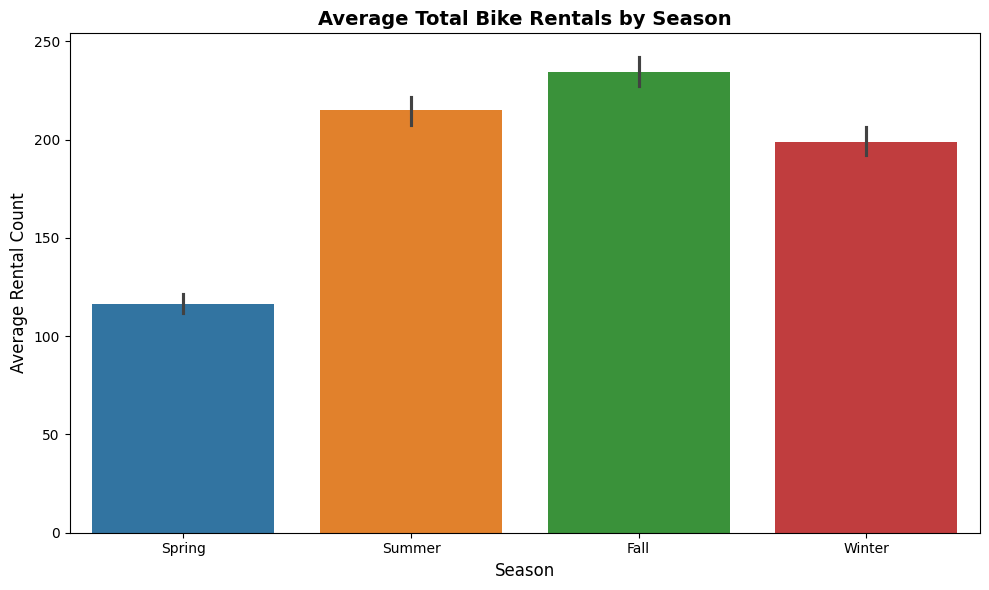

In [ ]:
# Bivariate Analysis: Overall Count vs Season

plt.figure(figsize=(10, 6))
sns.barplot(data=yulu,x='season_name',y='overall_count',hue='season_name',legend=False)

plt.title('Average Total Bike Rentals by Season', fontsize=14, fontweight='bold')
plt.xlabel('Season', fontsize=12)
plt.ylabel('Average Rental Count', fontsize=12)

plt.tight_layout()
plt.show()

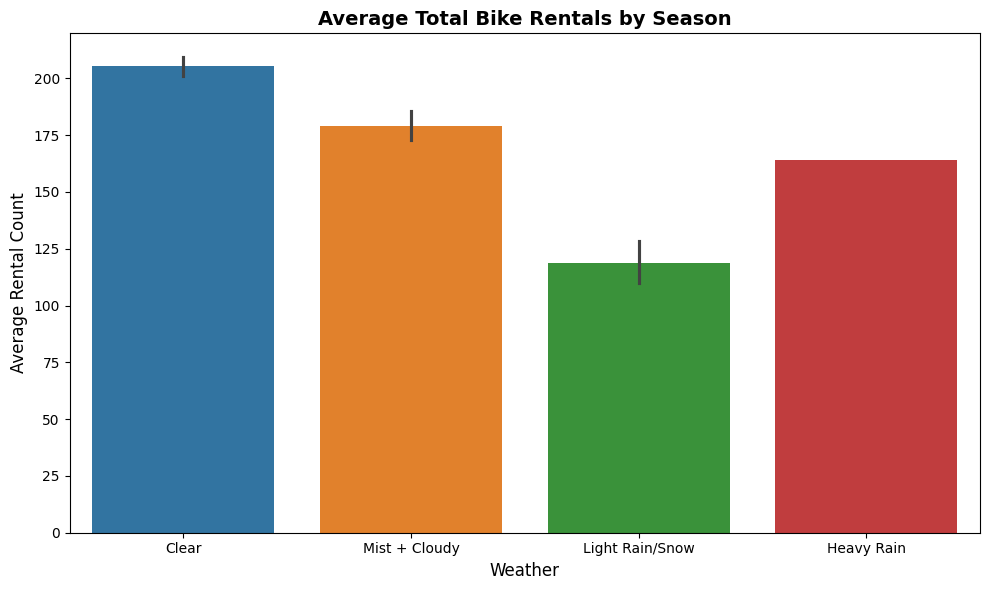

In [ ]:
# Bivariate Analysis: Overall Count vs Weather

plt.figure(figsize=(10, 6))
sns.barplot(data=yulu,x='weather_name',y='overall_count',hue='weather_name',legend=False)

plt.title('Average Total Bike Rentals by Season', fontsize=14, fontweight='bold')
plt.xlabel('Weather', fontsize=12)
plt.ylabel('Average Rental Count', fontsize=12)

plt.tight_layout()
plt.show()

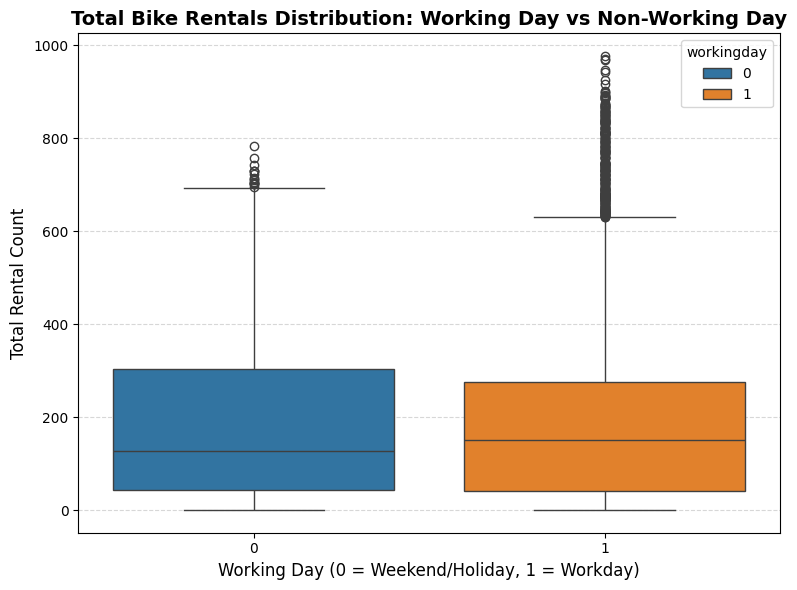

In [ ]:
# Bivariate Analysis: Overall Count vs Working Day

plt.figure(figsize=(8, 6))

sns.boxplot(data=yulu, x='workingday', y='overall_count',hue ='workingday')

plt.title('Total Bike Rentals Distribution: Working Day vs Non-Working Day', fontsize=14, fontweight='bold')
plt.xlabel('Working Day (0 = Weekend/Holiday, 1 = Workday)', fontsize=12)
plt.ylabel('Total Rental Count', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

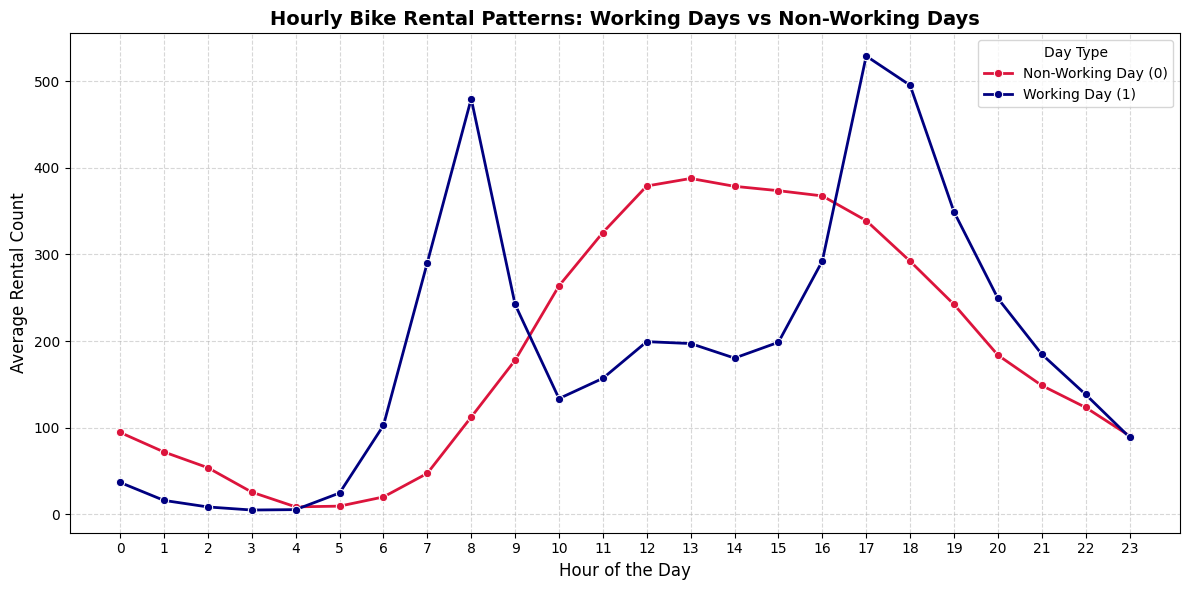

In [ ]:
# Bivariate Analysis: Overall Count vs Hourly Pattern by Working Day

plt.figure(figsize=(12, 6))

sns.lineplot(data=yulu, x='hour', y='overall_count', hue='workingday',
             marker='o', palette={0: 'crimson', 1: 'navy'}, linewidth=2, errorbar=None)

plt.title('Hourly Bike Rental Patterns: Working Days vs Non-Working Days', fontsize=14, fontweight='bold')
plt.xlabel('Hour of the Day', fontsize=12)
plt.ylabel('Average Rental Count', fontsize=12)
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Day Type', labels=['Non-Working Day (0)', 'Working Day (1)'])
plt.tight_layout()
plt.show()

# ***Outliers - Analysis***

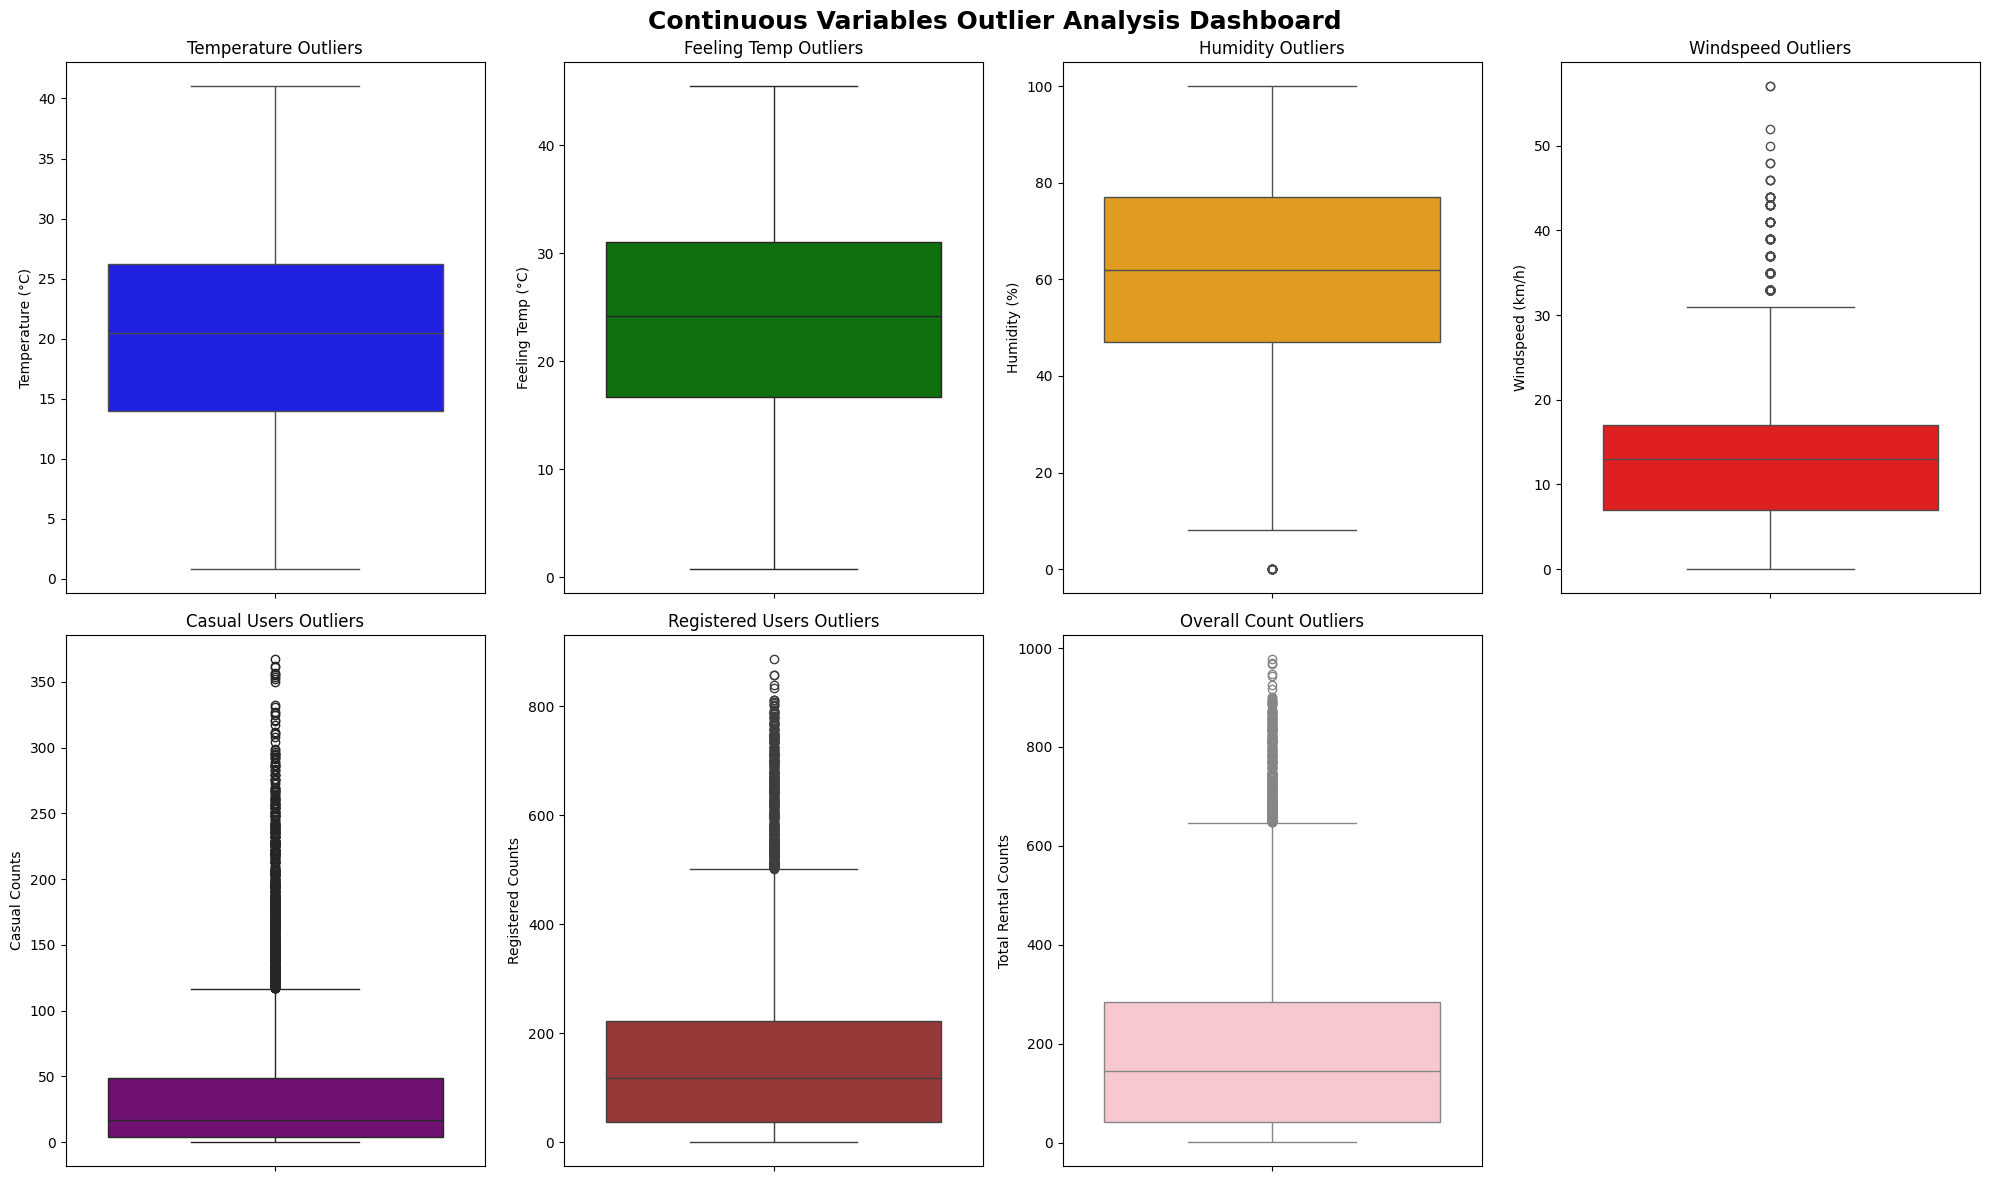

In [ ]:
# Initialize a single consolidated figure tab
fig = plt.figure(figsize=(20, 12))

# 1. Temperature Outliers
plt.subplot(2, 4, 1)
sns.boxplot(y=yulu['temp'], color='blue')
plt.title("Temperature Outliers")
plt.ylabel("Temperature (°C)")

# 2. Feeling Temperature Outliers
plt.subplot(2, 4, 2)
sns.boxplot(y=yulu['atemp'], color='green')
plt.title("Feeling Temp Outliers")
plt.ylabel("Feeling Temp (°C)")

# 3. Humidity Outliers
plt.subplot(2, 4, 3)
sns.boxplot(y=yulu['humidity'], color='orange')
plt.title("Humidity Outliers")
plt.ylabel("Humidity (%)")

# 4. Windspeed Outliers
plt.subplot(2, 4, 4)
sns.boxplot(y=yulu['windspeed'], color='red')
plt.title("Windspeed Outliers")
plt.ylabel("Windspeed (km/h)")

# 5. Casual Users Outliers
plt.subplot(2, 4, 5)
sns.boxplot(y=yulu['casual_users_count'], color='purple')
plt.title("Casual Users Outliers")
plt.ylabel("Casual Counts")

# 6. Registered Users Outliers
plt.subplot(2, 4, 6)
sns.boxplot(y=yulu['reg_users_count'], color='brown')
plt.title("Registered Users Outliers")
plt.ylabel("Registered Counts")

# 7. Overall Count Outliers
plt.subplot(2, 4, 7)
sns.boxplot(y=yulu['overall_count'], color='pink')
plt.title("Overall Count Outliers")
plt.ylabel("Total Rental Counts")

# Main title and clean layout padding
fig.suptitle('Continuous Variables Outlier Analysis Dashboard', fontsize=18, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

# ***Correlation Matrix Heatmap***

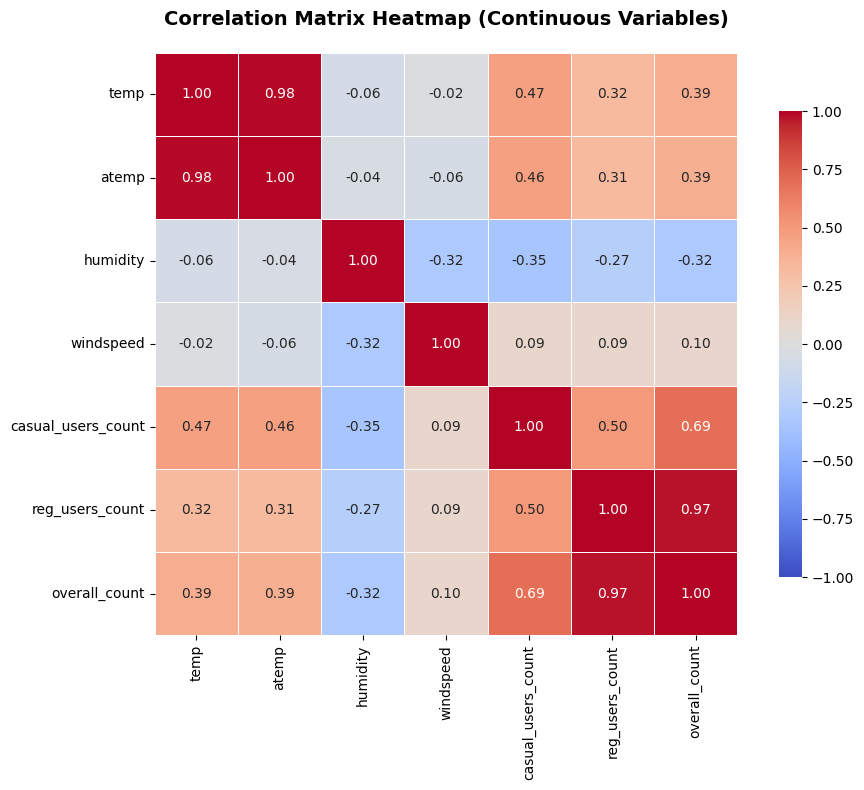

In [ ]:
# 1. Select the continuous quantitative variables
continuous_cols = ['temp', 'atemp', 'humidity', 'windspeed', 'casual_users_count', 'reg_users_count', 'overall_count']

# 2. Calculate the Pearson correlation matrix
corr_matrix = yulu[continuous_cols].corr()

# 3. Set up the matplotlib figure size
plt.figure(figsize=(10, 8))

# 4. Generate the heatmap with annotations and a clear diverging color palette
sns.heatmap(corr_matrix,
            annot=True,          # Display the numerical correlation coefficients
            cmap='coolwarm',     # Red for positive correlation, blue for negative correlation
            fmt=".2f",           # Round values to 2 decimal places
            linewidths=0.5,      # Add a thin line separating the cells
            square=True,         # Force cells to be square-shaped
            cbar_kws={"shrink": .8},
            vmin=-1, vmax=1)     # Standardize colorbar limits between -1 and +1

# 5. Title and formatting layout
plt.title('Correlation Matrix Heatmap (Continuous Variables)', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()

# 6. Render plot
plt.show()

# ***Hypothesis Testing - 2 Sample T-Test***



**Question: Check if Working Day has an effect on the number of electric cycles rented.**

**Gather Raw data for Sampling the data**

In [ ]:
# Overall data count at "workingday" level
yulu.groupby('workingday')['overall_count'].size().reset_index()

,workingday,overall_count
0,0,3474
1,1,7412


In [ ]:
# Raw data
working_day = yulu[yulu['workingday'] == 1]['overall_count']
non_working_day = yulu[yulu['workingday'] == 0]['overall_count']
print(working_day)
print(non_working_day)

47         5
48         2
49         1
50         3
51        30
        ... 
10881    336
10882    241
10883    168
10884    129
10885     88
Name: overall_count, Length: 7412, dtype: int64
0         16
1         40
2         32
3         13
4          1
        ... 
10809    109
10810    122
10811    106
10812     89
10813     33
Name: overall_count, Length: 3474, dtype: int64


In [ ]:
# Sampling the data
np.random.seed(42)  # For consistent results
sample_working = np.random.choice(working_day, size=3000, replace=False)
sample_non_working = np.random.choice(non_working_day, size=3000, replace=False)

***Shapiro-Wilk Test***

In [ ]:
H0 = "Data follows a normal distribution"
Ha = "Data does not follow a normal distribution"
print(f"1. Null Hypothesis: {H0} and Alternate Hypothesis: {Ha}")

alpha = 0.05
print(f"2. Significance Level (alpha): {alpha}")

#calculation
stat_working, p_value_working = stats.shapiro(sample_working)
stat_not_working, p_value_not_working = stats.shapiro(sample_non_working)


print(f"3. For Working days sample data, Stat is {stat_working} and P Value is {p_value_working}")
print(f"4. For Non-Working days sample data, Stat is {stat_not_working} and P Value is {p_value_not_working}")

p_value_status_working = (
    "Working day data is normally distributed, Hence Fail to Reject H0"
    if p_value_working > alpha
    else "Working day data is not normally distributed, Hence Reject H0")

p_value_status_not_working = (
    "Non-Working day data is normally distributed, Hence Fail to Reject H0"
    if p_value_not_working > alpha
    else "Non-Working day data is not normally distributed, Hence Reject H0")

print(f"5. Shapiro-Wilk Test for Working Sample Data: {p_value_status_working}")
print(f"6. Shapiro-Wilk Test for Non-Working Sample Data: {p_value_status_not_working}")

print("7. Decision: Since both P-values are < 0.05, the data is not normal")
print("8. However, because the original sample size is large (N > 30), the Central Limit Theorem allows us to safely proceed with the T-test")

1. Null Hypothesis: Data follows a normal distribution and Alternate Hypothesis: Data does not follow a normal distribution
2. Significance Level (alpha): 0.05
3. For Working days sample data, Stat is 0.8778080225417806 and P Value is 1.4641284740766062e-43
4. For Non-Working days sample data, Stat is 0.8842459965518578 and P Value is 1.0051077662682144e-42
5. Shapiro-Wilk Test for Working Sample Data: Working day data is not normally distributed, Hence Reject H0
6. Shapiro-Wilk Test for Non-Working Sample Data: Non-Working day data is not normally distributed, Hence Reject H0
7. Decision: Since both P-values are < 0.05, the data is not normal
8. However, because the original sample size is large (N > 30), the Central Limit Theorem allows us to safely proceed with the T-test


**Levene's Test for Equal Variance**

In [ ]:
H0 = "Variance are equal"
Ha = "Variance are not equal"
print(f"1. Null Hypothesis: {H0} & Alternate Hypothesis: {Ha}")
alpha = 0.05
print(f"2. Significance Level (alpha): {alpha}")

#calculation
stat, p_value = stats.levene(working_day, non_working_day)
print(f"3. Statistics value is {stat} and P value is {p_value}")

p_value_status = (
    "Variances are equal, Hence Fail to Reject H0"
    if p_value > alpha
    else "Variances are not equal, Hence Reject H0"
)

print(f"4. Levene Test result: {p_value_status}")


if p_value > alpha:
    print(f"5. Decision: Since the P-value ({p_value:.4f}) is > {alpha}, we FAIL TO REJECT H0.")
    print("   This confirms that the variance between working days and non-working days is statistically identical.")
    print("   -- Hence, satisfying the crucial equal variance assumption required for a standard parametric T-test.")
else:
    print(f"5. Decision: Since the P-value ({p_value:.4f}) is <= {alpha}, we REJECT H0.")
    print("   The variances are fundamentally unequal. If moving to a T-test, Welch's T-test (equal_var=False) must be used.")

1. Null Hypothesis: Variance are equal & Alternate Hypothesis: Variance are not equal
2. Significance Level (alpha): 0.05
3. Statistics value is 0.004972848886504472 and P value is 0.9437823280916695
4. Levene Test result: Variances are equal, Hence Fail to Reject H0
5. Decision: Since the P-value (0.9438) is > 0.05, we FAIL TO REJECT H0.
   This confirms that the variance between working days and non-working days is statistically identical.
   -- Hence, satisfying the crucial equal variance assumption required for a standard parametric T-test.


**2-Sample T-Test**

In [ ]:
H0 = "Working day has no effect on the number of electric cycles rented."
Ha = "Working day has an effect on the number of electric cycles rented."
print(f"1. Null Hypothesis: {H0}")
print(f"Alternate Hypothesis: {Ha}")

alpha = 0.05
print(f"2. Significance Level (alpha): {alpha}")

#calculation
t_stat, p_value = stats.ttest_ind(sample_working, sample_non_working, alternative='two-sided')
print(f"3. T status is {t_stat}")
print(f"4. P value is {p_value}")

p_value_status = (
    "Decision-Reject the Null Hypothesis. Working day has an effect on rentals"
    if p_value < alpha else "Decision-Failed to reject the Null Hypothesis. Working day has NO significant effect on rentals.")

print(f"5. 2 Sample T-Test result: {p_value_status}")


1. Null Hypothesis: Working day has no effect on the number of electric cycles rented.
Alternate Hypothesis: Working day has an effect on the number of electric cycles rented.
2. Significance Level (alpha): 0.05
3. T status is 0.8490851741012875
4. P value is 0.3958677858633044
5. 2 Sample T-Test result: Decision-Failed to reject the Null Hypothesis. Working day has NO significant effect on rentals.


# ***Hypothesis Testing:  Chi-square***

**Question: Check if Weather is dependent on the season.**

In [ ]:
# Creating contingency table using Crosstab

observed_data = pd.crosstab(yulu['season_name'],yulu['weather_name'])
observed_data

weather_name,Clear,Heavy Rain,Light Rain/Snow,Mist + Cloudy
season_name,,,,
Fall,1930,0,199,604
Spring,1759,1,211,715
Summer,1801,0,224,708
Winter,1702,0,225,807


In [ ]:
H0 = "Weather and Season are independent of each other (no relationship)"
Ha = "Weather and Season are dependent on each other (significant relationship)"
print(f"1. Null Hypothesis: {H0}")
print(f"   Alternate Hypothesis: {Ha}")

alpha = 0.05
print(f"2. Significance Level (alpha): {alpha}")

#calculation
chi_stat,p_value,dof,expected_freq=chi2_contingency(observed_data)
print(f"3. Chi-Square Test: {chi_stat}")
print(f"4. P Value: {p_value}")
print(f"5. Degree of freedom: {dof}")
print(f"6. Expected Frequency value: {expected_freq} ")

p_value_status = (
    "Decision-Reject the Null Hypothesis. Weather and Season are dependent on each other"
    if p_value < alpha else "Decision-Failed to reject the Null Hypothesis. Weather and Season are Independent of each other.")

print(f"7. Chi-Squared Hypothesis result: {p_value_status}")

1. Null Hypothesis: Weather and Season are independent of each other (no relationship)
   Alternate Hypothesis: Weather and Season are dependent on each other (significant relationship)
2. Significance Level (alpha): 0.05
3. Chi-Square Test: 49.158655596893624
4. P Value: 1.549925073686492e-07
5. Degree of freedom: 9
6. Expected Frequency value: [[1.80559765e+03 2.51056403e-01 2.15657450e+02 7.11493845e+02]
 [1.77454639e+03 2.46738931e-01 2.11948742e+02 6.99258130e+02]
 [1.80559765e+03 2.51056403e-01 2.15657450e+02 7.11493845e+02]
 [1.80625831e+03 2.51148264e-01 2.15736359e+02 7.11754180e+02]] 
7. Chi-Squared Hypothesis result: Decision-Reject the Null Hypothesis. Weather and Season are dependent on each other


# ***Hypothesis Testing - ANOVA - Cycle Rented vs Season***

In [ ]:
# Getting Raw data:
s_spring = yulu[yulu['season_name'] == 'Spring']['overall_count']
s_summer = yulu[yulu['season_name'] == 'Summer']['overall_count']
s_fall = yulu[yulu['season_name'] == 'Fall']['overall_count']
s_winter = yulu[yulu['season_name'] == 'Winter']['overall_count']

In [ ]:
# Normality Sample
shapiro_s_spring = np.random.choice(s_spring, size=500, replace=False)
shapiro_s_summer = np.random.choice(s_summer, size=500, replace=False)
shapiro_s_fall = np.random.choice(s_fall, size=500, replace=False)
shapiro_s_winter = np.random.choice(s_winter, size=500, replace=False)

In [ ]:
# Shapiro Test:
print(f"Normality (Shapiro) P-values:\n"
      f"  - Spring: {stats.shapiro(shapiro_s_spring)[1]:.4e}\n"
      f"  - Summer: {stats.shapiro(shapiro_s_summer)[1]:.4e}\n"
      f"  - Fall:   {stats.shapiro(shapiro_s_fall)[1]:.4e}\n"
      f"  - Winter: {stats.shapiro(shapiro_s_winter)[1]:.4e}")

Normality (Shapiro) P-values:
  - Spring: 2.3762e-24
  - Summer: 1.3473e-18
  - Fall:   3.3522e-16
  - Winter: 3.6106e-16


In [ ]:
# Levene Test
levene_s_p = stats.levene(s_spring, s_summer, s_fall, s_winter)[1]
print(f"Equal Variance (Levene) P-value: {levene_s_p:.4e}")

Equal Variance (Levene) P-value: 1.0147e-118


In [ ]:
# One-Way ANOVA Test
H0 = "The average number of electric cycles rented is identical across all four seasons."
Ha = "The average number of electric cycles rented is significantly different in at least one season."

print(f"1. Null Hypothesis (H0): {H0}")
print(f"   Alternate Hypothesis (Ha): {Ha}")


# 2. Significance level = 0.05
alpha = 0.05
print(f"2. Significance Level (alpha): {alpha}\n")


# 3. Run test
f_stat_s, p_val_s = stats.f_oneway(s_spring, s_summer, s_fall, s_winter)


# 4. Print Stat value
print(f"4. ANOVA F-Statistic Value: {f_stat_s:.4f}")


# 5. Print P value
print(f"5. Calculated P-Value: {p_val_s:.4e}\n")


# 6. Based on the P value and Significance value accept or reject null hypothesis
p_value_status = (
    "Decision: Reject the Null Hypothesis (H0). There is a statistically significant difference across seasons."
    if p_val_s < alpha
    else "Decision: Failed to reject the Null Hypothesis (H0). There is no significant difference across seasons."
)
print(f"6. ANOVA Evaluation Result:\n   {p_value_status}\n")


# 7. Business Explanation
print("7. Business Explanation:")
print("   Because the P-value is effectively zero (drastically lower than 0.05), we confidently reject H0.")
print("   This proves that consumer demand for Yulu electric cycles is highly dependent on the season of the year.")
print("   Operational takeaway: Higher demand shifts during peak seasons (like Summer and Fall) mean that logistics")
print("   teams must prepare for accelerated battery depletion cycles, expand warehouse field readiness, and schedule")
print("   preventative bike fleet maintenance during lower-demand seasons (like Spring).")

1. Null Hypothesis (H0): The average number of electric cycles rented is identical across all four seasons.
   Alternate Hypothesis (Ha): The average number of electric cycles rented is significantly different in at least one season.
2. Significance Level (alpha): 0.05

4. ANOVA F-Statistic Value: 236.9467
5. Calculated P-Value: 6.1648e-149

6. ANOVA Evaluation Result:
   Decision: Reject the Null Hypothesis (H0). There is a statistically significant difference across seasons.

7. Business Explanation:
   Because the P-value is effectively zero (drastically lower than 0.05), we confidently reject H0.
   This proves that consumer demand for Yulu electric cycles is highly dependent on the season of the year.
   Operational takeaway: Higher demand shifts during peak seasons (like Summer and Fall) mean that logistics
   teams must prepare for accelerated battery depletion cycles, expand warehouse field readiness, and schedule
   preventative bike fleet maintenance during lower-demand seaso

# ***Hypothesis Testing - ANOVA - Cycle Rented vs Weather***

**Question: check if No. of cycles rented is similar or different in different Weather**

In [ ]:
# Filter out 'Heavy Rain' (N=1) to allow variance/normality calculations
yulu_weather = yulu[yulu['weather_name'] != 'Heavy Rain']

In [ ]:
# Getting Raw data:
w_clear = yulu_weather[yulu_weather['weather_name'] == 'Clear']['overall_count']
w_mist = yulu_weather[yulu_weather['weather_name'] == 'Mist + Cloudy']['overall_count']
w_rain = yulu_weather[yulu_weather['weather_name'] == 'Light Rain/Snow']['overall_count']

In [ ]:
# Normality Samples (Size 750)
np.random.seed(42)
shapiro_w_clear = np.random.choice(w_clear, size=750, replace=False)
shapiro_w_mist = np.random.choice(w_mist, size=750, replace=False)
shapiro_w_rain = np.random.choice(w_rain, size=750, replace=False)

**Shapiro-Wilk Test**

In [ ]:
H0 = "Data follows a normal distribution"
Ha = "Data does not follow a normal distribution"
print(f"1. Null Hypothesis: {H0} and Alternate Hypothesis: {Ha}")

alpha = 0.05
print(f"2. Significance Level (alpha): {alpha}")

#calculation
stat_w_clear, p_value_w_clear = stats.shapiro(shapiro_w_clear)
stat_w_mist, p_value_w_mist = stats.shapiro(shapiro_w_mist)
stat_w_rain, p_value_w_rain = stats.shapiro(shapiro_w_rain)


print(f"3. For Clear Weather, Stat is {stat_w_clear} and P Value is {p_value_w_clear}")
print(f"4. For Mist Weather, Stat is {stat_w_mist} and P Value is {p_value_w_mist}")
print(f"5. For Rain Weather, Stat is {stat_w_rain} and P Value is {p_value_w_rain}")


p_value_w_clear_status = (
    "Clear Weather data is normally distributed, Hence Fail to Reject H0"
    if p_value_w_clear > alpha
    else "Clear Weather data is not normally distributed, Hence Reject H0")

p_value_w_mist_status = (
    "Mist Weather data is normally distributed, Hence Fail to Reject H0"
    if p_value_w_mist > alpha
    else "Mist Weather data is not normally distributed, Hence Reject H0")

p_value_w_rain_status = (
    "Rain Weather data is normally distributed, Hence Fail to Reject H0"
    if p_value_w_rain > alpha
    else "Rain Weather data is not normally distributed, Hence Reject H0")



print(f"6. Shapiro-Wilk Test for Clear Weather: {p_value_w_clear_status}")
print(f"7. Shapiro-Wilk Test for Mist Weather: {p_value_w_mist_status}")
print(f"8. Shapiro-Wilk Test for Raining Weather: {p_value_w_rain_status}")

print("9. Since the P-values for all three weather samples are significantly less than alpha. we reject the Null Hypothesis for each group")
print("10.There is strong statistical evidence to conclude that the number of cycles rented under each weather is not normally distributed")
print("11. As data is not normally distributed, we will do Kruskal-Wallis Test")

1. Null Hypothesis: Data follows a normal distribution and Alternate Hypothesis: Data does not follow a normal distribution
2. Significance Level (alpha): 0.05
3. For Clear Weather, Stat is 0.880466449964392 and P Value is 1.4394636827417038e-23
4. For Mist Weather, Stat is 0.8763972688392223 and P Value is 6.306062426074737e-24
5. For Rain Weather, Stat is 0.7691237576504985 and P Value is 3.796924269177179e-31
6. Shapiro-Wilk Test for Clear Weather: Clear Weather data is not normally distributed, Hence Reject H0
7. Shapiro-Wilk Test for Mist Weather: Mist Weather data is not normally distributed, Hence Reject H0
8. Shapiro-Wilk Test for Raining Weather: Rain Weather data is not normally distributed, Hence Reject H0
9. Since the P-values for all three weather samples are significantly less than alpha. we reject the Null Hypothesis for each group
10.There is strong statistical evidence to conclude that the number of cycles rented under each weather is not normally distributed
11. As da

**Kruskal-Wallis**

In [ ]:

# 1. Filter data (Excluding Heavy Rain since N=1)
yulu_weather = yulu[yulu['weather_name'] != 'Heavy Rain']

w_clear = yulu_weather[yulu_weather['weather_name'] == 'Clear']['overall_count']
w_mist = yulu_weather[yulu_weather['weather_name'] == 'Mist + Cloudy']['overall_count']
w_rain = yulu_weather[yulu_weather['weather_name'] == 'Light Rain/Snow']['overall_count']



# a. Define Hypotheses
H0 = "The median number of cycles rented is the same across all weather categories."
Ha = "At least one weather category has a significantly different median number of cycles rented."

print(f"1. Null Hypothesis (H0): {H0}")
print(f"   Alternate Hypothesis (Ha): {Ha}")

alpha = 0.05
print(f"2. Significance Level (alpha): {alpha}\n")

# b. Calculation
k_stat, p_value_kfile = stats.kruskal(w_clear, w_mist, w_rain)

print(f"3. Kruskal-Wallis H-statistic: {k_stat:.4f}")
print(f"4. Calculated P-value: {p_value_kfile:.4e}\n")

# c. Evaluation Logic
decision_status = (
    "Decision: Reject the Null Hypothesis (H0). Weather has a statistically significant effect on cycle rentals."
    if p_value_kfile < alpha
    else "Decision: Failed to reject the Null Hypothesis (H0). Weather has no significant effect on cycle rentals."
)

print(f"5. Hypothesis Result:\n   {decision_status}\n")

# =====================================================================
# Business Inference
# =====================================================================
print("--- Business Explanation ---")
print("Because the P-value is effectively 0 (less than 0.05), we confidently reject H0.")
print("Even without relying on normality assumptions, the rank-order distributions prove that weather")
print("heavily impacts consumer habits. Rentals drastically drop during rain/snow compared to clear days.")
print("Actionable strategy: Yulu should scale down battery swapping tasks and roadside tracking deployments")
print("during forecasted rainy days, while prioritizing full inventory placement during clear weather window cycles.")

1. Null Hypothesis (H0): The median number of cycles rented is the same across all weather categories.
   Alternate Hypothesis (Ha): At least one weather category has a significantly different median number of cycles rented.
2. Significance Level (alpha): 0.05

3. Kruskal-Wallis H-statistic: 204.9557
4. Calculated P-value: 3.1221e-45

5. Hypothesis Result:
   Decision: Reject the Null Hypothesis (H0). Weather has a statistically significant effect on cycle rentals.

--- Business Explanation ---
Because the P-value is effectively 0 (less than 0.05), we confidently reject H0.
Even without relying on normality assumptions, the rank-order distributions prove that weather
heavily impacts consumer habits. Rentals drastically drop during rain/snow compared to clear days.
Actionable strategy: Yulu should scale down battery swapping tasks and roadside tracking deployments
during forecasted rainy days, while prioritizing full inventory placement during clear weather window cycles.
